In [1]:
from astropy import units as u
from astroquery.gaia import Gaia
import matplotlib.pyplot as plt
import csv
import numpy as np
from astropy.coordinates import SkyCoord  # High-level coordinates

In [2]:
distlim = 1000 / (200 * u.pc)
errorlim = 10

query = f"""SELECT 
    ra, ra_error, dec, dec_error, parallax, parallax_error, 
    pmra, pmra_error, pmdec, pmdec_error, 
    phot_g_mean_mag, bp_rp, ag_gspphot, ruwe 
from gaiadr3.gaia_source
WHERE parallax_over_error >= {10} 
AND parallax >= {5}
"""


job = Gaia.launch_job_async(query)
result = job.get_results()

print(f'Table size (rows): {len(result)}')

INFO: Query finished. [astroquery.utils.tap.core]
Table size (rows): 2234316


In [4]:
results = result

In [5]:
results['abs_mag'] = results['phot_g_mean_mag'] + 5 + 5 * np.log10(results['parallax'] / 1000)

In [62]:
#1.e cuts
# sky pos, parallax, proper motion cuts
pleiades = SkyCoord.from_name('Pleiades')

# from paper
ra = pleiades.ra.to(u.deg).value
dec = pleiades.dec.to(u.deg).value
paral = 7.364
per = 0.005
pmra = 19.997
pmraer = 0.127
pmdec = -45.548
pmdecer = 0.101

coords = SkyCoord(results['ra'], results['dec'], frame='icrs', unit='deg')

#posmask = (np.abs(results['ra']) - ra < 20) & (np.abs(results['dec']) - dec < 20) 
posmask = coords.separation(pleiades).deg < 20
prxmask = (np.abs(results['parallax']) - paral) < 1
pmramask = np.abs(results['pmra'] - pmra) < 3
pmdecmask = np.abs(results['pmdec'] - pmdec) < 3
ruwemask = results['ruwe'] < 1.4

ple_mask = posmask & prxmask & pmramask & pmdecmask & ruwemask
ple = results[ple_mask]
len(ple)

1387

In [15]:
ple[0]

ra,ra_error,dec,dec_error,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag,bp_rp,ag_gspphot,ruwe,abs_mag
deg,mas,deg,mas,mas,mas,mas / yr,mas / yr,mas / yr,mas / yr,mag,mag,mag,,
float64,float32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32,float32,float32,float64
45.385971319362554,0.04866897,1.6935922558122118,0.05123181,5.015246572366304,0.056683246,21.031152665369454,0.061212253,-44.25091515643749,0.06826632,16.241674,2.4777517,0.4441,0.9626001,9.743135872099298


In [18]:
names = ['ra', 'ra_error', 'dec', 'dec_error', 'parallax', 'parallax_error', 'pmra', 'pmra_error', 'pmdec', 'pmdec_error', 'phot_g_mean_mag', 'bp_rp', 'ag_gspphot', 'ruwe', 'abs_mag']

In [63]:
outputfile = 'plestars.csv'
with open(outputfile, 'w', newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=names)
    writer.writeheader()
    writer.writerows(ple)

In [19]:
ples = np.genfromtxt('plestars.csv', dtype=None, skip_header=True, names=names)

In [41]:
outputfile = 'plestars.csv'

import pandas as pd

dat = pd.read_csv(outputfile, sep=',', header='infer', index_col=False)

In [45]:
import numpy as np
import pandas as pd

# Read the CSV file
csv_path = 'plestars.csv'
df = pd.read_csv(csv_path)

# Get column names
column_names = df.columns.tolist()

# Convert all data to float (handles '--' or other non-numeric values as NaN)
data_array = df.apply(pd.to_numeric, errors='coerce').values
'''
print("Column names:")
print(column_names)
print("\nData array shape:", data_array.shape)
print("\nData type:", data_array.dtype)
print("\nFirst 5 rows:")
print(data_array[:5])
'''
# Alternative: Create a structured array with column names
# This keeps column names attached to the data
dtype_list = [(col, float) for col in column_names]
structured_array = np.zeros(len(df), dtype=dtype_list)

for col in column_names:
    structured_array[col] = pd.to_numeric(df[col], errors='coerce')
'''
print("\n--- Structured Array ---")
print("Column names:", structured_array.dtype.names)
print("\nFirst 5 rows:")
print(structured_array[:5])

# You can access columns by name like this:
print("\nExample - accessing 'ra' column:")
print(structured_array['ra'][:5])
'''

'\nprint("\n--- Structured Array ---")\nprint("Column names:", structured_array.dtype.names)\nprint("\nFirst 5 rows:")\nprint(structured_array[:5])\n\n# You can access columns by name like this:\nprint("\nExample - accessing \'ra\' column:")\nprint(structured_array[\'ra\'][:5])\n'

In [65]:
structured_array.size

1387

In [52]:
dist = 1000/np.mean(structured_array['parallax'])
dist

np.float64(136.96416426303642)

In [53]:
dat = structured_array

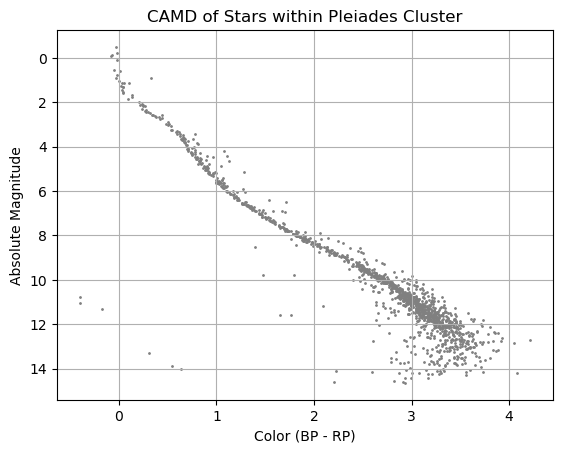

In [54]:
#plt.scatter(results['bp_rp'][ple_mask], results['abs_mag'][ple_mask], s=1, alpha=1, color='grey')
#plt.scatter(mamajekcol, mamajekG, label='Mamajek Points', color='gold')
#for i, label in enumerate(mamajeknames):
#    plt.annotate(label, (mamajekcol[i], mamajekG[i]), color='red', fontweight='bold', fontsize='12')#, textcoords='offset points', xytext(0, 10), ha='center')
plt.scatter(dat['bp_rp'], dat['abs_mag'], s=1, alpha=1, color='grey')
plt.gca().invert_yaxis()
#plt.xlim(-0.5, 5)
plt.grid()
plt.xlabel('Color (BP - RP)')
plt.ylabel('Absolute Magnitude')
plt.title('CAMD of Stars within Pleiades Cluster');
#plt.savefig('1ecamd.png')
#plt.legend();

,#,EEP,log10_isochrone_age_yr,initial_mass,star_mass,star_mdot,he_core_mass,c_core_mass,o_core_mass,log_L,...,conv_env_top_mass,conv_env_bot_mass,conv_env_top_radius,conv_env_bot_radius,conv_env_turnover_time_l_t,conv_env_turnover_time_l_b,conv_env_turnover_time_g,envelope_binding_energy,total_moment_of_inertia,phase
0,129,8.0000000000000000E+000,1.0053576990155919E-001,1.0053560255450333E-001,-1.9633244771163033E-016,0.0000000000000000E+000,0.0000000000000000E+000,0.0000000000000000E+000,-2.6047185735674430E+000,-6.3314810508675521E+000,...,0.0000000000000000E+000,1.8698741578443254E-001,0.0000000000000000E+000,-1.0000000000000001E+099,4.1516596694210082E+007,3.7114500894242890E+007,-8.9511733076248521E+046,7.3354392478986745E+051,-1.0000000000000000E+000,NaN
1,130,8.0000000000000000E+000,1.0360465621509798E-001,1.0360448334952382E-001,-2.0637691005463348E-016,0.0000000000000000E+000,0.0000000000000000E+000,0.0000000000000000E+000,-2.5894902933265551E+000,-6.3175252112903451E+000,...,0.0000000000000000E+000,1.9042495837897230E-001,0.0000000000000000E+000,-9.9999999999999997E+098,4.1812192197066054E+007,3.7392808425372981E+007,-9.3272209088072231E+046,8.1182979808395253E+051,-1.0000000000000000E+000,NaN
2,131,8.0000000000000000E+000,1.0699124004217991E-001,1.0699106104555385E-001,-2.1719277454073251E-016,0.0000000000000000E+000,0.0000000000000000E+000,0.0000000000000000E+000,-2.5721687210107476E+000,-6.3005549027231815E+000,...,0.0000000000000000E+000,1.9411450986015805E-001,0.0000000000000000E+000,-9.9999999999999997E+098,4.2083070233698390E+007,3.7663918023631029E+007,-9.7500420632543619E+046,8.9455355970073259E+051,-1.0000000000000000E+000,NaN
3,132,8.0000000000000000E+000,1.1034249826959214E-001,1.1034231316173604E-001,-2.2744104999725635E-016,0.0000000000000000E+000,0.0000000000000000E+000,0.0000000000000000E+000,-2.5547197854213222E+000,-6.2826974137396627E+000,...,0.0000000000000000E+000,1.9765276644412427E-001,0.0000000000000000E+000,-9.9999999999999997E+098,4.2311325327693604E+007,3.7905751888737820E+007,-1.0176949676102548E+047,9.7263886161758505E+051,-1.0000000000000000E+000,NaN
4,133,8.0000000000000000E+000,1.1368880293189322E-001,1.1368861168307666E-001,-2.3717621003944298E-016,0.0000000000000000E+000,0.0000000000000000E+000,0.0000000000000000E+000,-2.5370895803128497E+000,-6.2641922681553917E+000,...,0.0000000000000000E+000,2.0109768911814085E-001,0.0000000000000000E+000,-9.9999999999999997E+098,4.2524955587231152E+007,3.8130924692447342E+007,-1.0611080332593381E+047,1.0471884232393908E+052,-1.0000000000000000E+000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5622,1546,8.1799999999999997E+000,5.7394106283629762E+000,9.4762383162706354E-001,0.0000000000000000E+000,9.4762330140645934E-001,9.4622328435101744E-001,0.0000000000000000E+000,-1.4020201891331463E+000,-3.0832454642373381E+000,...,0.0000000000000000E+000,0.0000000000000000E+000,0.0000000000000000E+000,0.0000000000000000E+000,0.0000000000000000E+000,0.0000000000000000E+000,-2.2568092785459237E+044,1.0519427026647088E+050,6.0000000000000000E+000,NaN
5623,1547,8.1799999999999997E+000,5.7876758590931523E+000,9.5158037886752078E-001,0.0000000000000000E+000,9.5157987161938462E-001,9.5024007648865738E-001,0.0000000000000000E+000,-1.4069750153484355E+000,-3.0776467437768265E+000,...,0.0000000000000000E+000,0.0000000000000000E+000,0.0000000000000000E+000,0.0000000000000000E+000,0.0000000000000000E+000,0.0000000000000000E+000,-2.1752473381870530E+044,1.0435538464774489E+050,6.0000000000000000E+000,NaN
5624,1548,8.1799999999999997E+000,6.0770336404230552E+000,9.7284759130208776E-001,0.0000000000000000E+000,9.7284721383044204E-001,9.7161272780530350E-001,0.0000000000000000E+000,-1.4362449820020760E+000,-3.0465142375377914E+000,...,0.0000000000000000E+000,0.0000000000000000E+000,0.0000000000000000E+000,0.0000000000000000E+000,0.0000000000000000E+000,0.0000000000000000E+000,-1.7150570771482901E+044,9.9871728134564258E+049,6.

Column names:
['Zini', 'MH', 'logAge', 'Mini', 'int_IMF', 'Mass', 'logL', 'logTe', 'logg', 'label', 'McoreTP', 'C_O', 'period0', 'period1', 'period2', 'period3', 'period4', 'pmode', 'Mloss', 'tau1m', 'X', 'Y', 'Xc', 'Xn', 'Xo', 'Cexcess', 'Z', 'Teff0', 'omega', 'angvel', 'vtaneq', 'angmom', 'Rpol', 'Req', 'mbolmag', 'G_fSBmag', 'G_BP_fSBmag', 'G_RP_fSBmag', 'G_fSB', 'G_f0', 'G_fk', 'G_i00', 'G_i05', 'G_i10', 'G_i15', 'G_i20', 'G_i25', 'G_i30', 'G_i35', 'G_i40', 'G_i45', 'G_i50', 'G_i55', 'G_i60', 'G_i65', 'G_i70', 'G_i75', 'G_i80', 'G_i85', 'G_i90', 'G_BP_fSB', 'G_BP_f0', 'G_BP_fk', 'G_BP_i00', 'G_BP_i05', 'G_BP_i10', 'G_BP_i15', 'G_BP_i20', 'G_BP_i25', 'G_BP_i30', 'G_BP_i35', 'G_BP_i40', 'G_BP_i45', 'G_BP_i50', 'G_BP_i55', 'G_BP_i60', 'G_BP_i65', 'G_BP_i70', 'G_BP_i75', 'G_BP_i80', 'G_BP_i85', 'G_BP_i90', 'G_RP_fSB', 'G_RP_f0', 'G_RP_fk', 'G_RP_i00', 'G_RP_i05', 'G_RP_i10', 'G_RP_i15', 'G_RP_i20', 'G_RP_i25', 'G_RP_i30', 'G_RP_i35', 'G_RP_i40', 'G_RP_i45', 'G_RP_i50', 'G_RP_i55', 'G_R

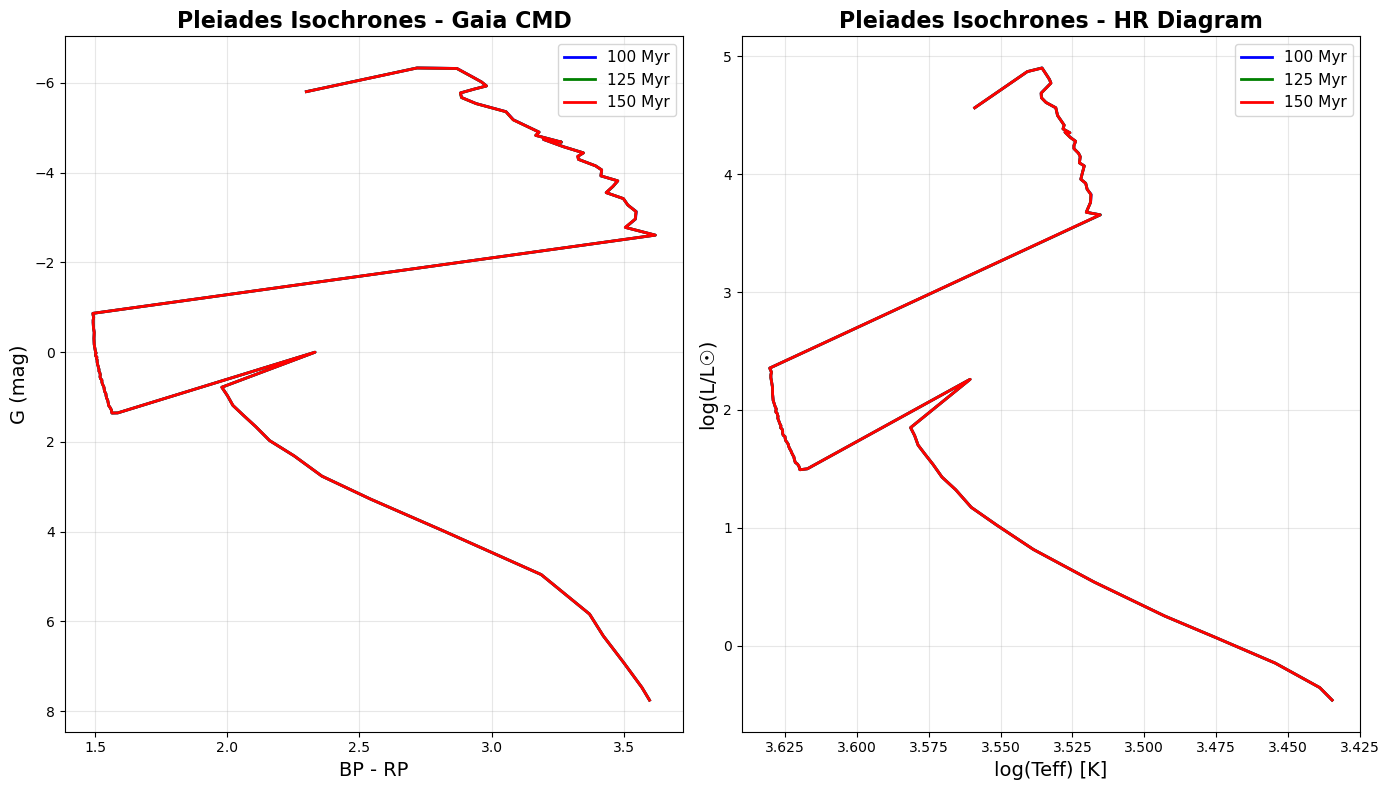


✓ Saved zoomed MS plot to pleiades_isochrones_ms.png


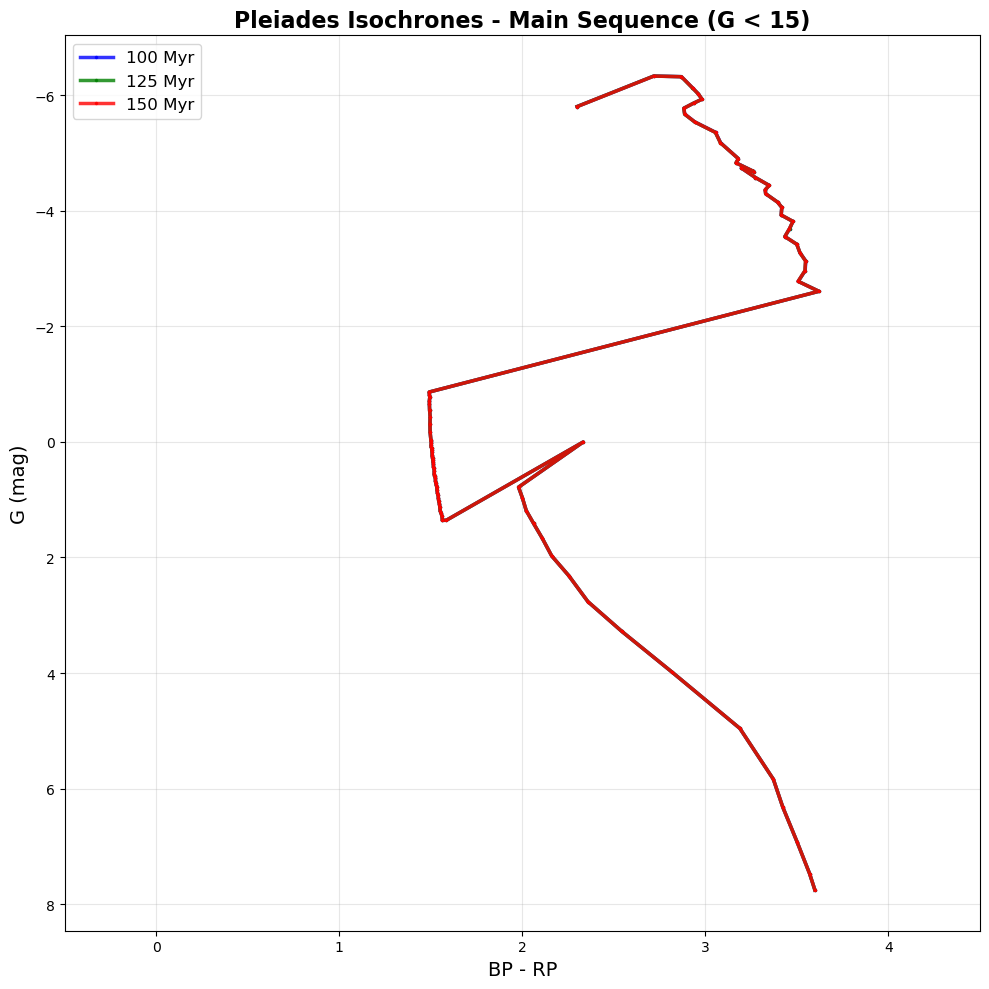

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the PARSEC isochrone file
# The column names are on line 14 (13 if 0-indexed), starting with "# Zini"
# We need to read this line as the header and skip the previous comment lines

# First, read the header line
with open('output978905827346.dat', 'r') as f:
    for i, line in enumerate(f):
        if i == 13:  # Line 14 (0-indexed)
            # Remove leading "# " and split
            header = line.strip().replace('# ', '').split()
            break

# Now read the data, skipping all comment lines
df = pd.read_csv('output978905827346.dat', 
                 sep=r'\s+', 
                 comment='#',
                 names=header)

print("Column names:")
print(df.columns.tolist())
print(f"\nTotal rows: {len(df)}")
print(f"\nUnique ages (logAge): {sorted(df['logAge'].unique())}")
print(f"\nAge range in Myr: {10**(df['logAge'].min()) * 1000:.1f} - {10**(df['logAge'].max()) * 1000:.1f}")

# The file has G_fSBmag, G_BP_fSBmag, G_RP_fSBmag columns
# These are the standard Gaia magnitudes without extinction

# Filter for the three ages you requested (should be in the file)
# Let's find what ages are actually present
unique_ages = sorted(df['logAge'].unique())
print(f"\nAges present in file:")
for age in unique_ages:
    age_myr = 10**(age) * 1000  # logAge is log10(Age in Gyr), so convert to Myr
    print(f"  logAge = {age:.3f}  ({age_myr:.1f} Myr)")

# Create Color-Magnitude Diagram (CMD)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

# Plot 1: Gaia CMD (BP-RP vs G)
colors = ['blue', 'green', 'red', 'purple', 'orange']
for i, age in enumerate(unique_ages):
    iso = df[df['logAge'] == age]
    age_myr = 10**(age) * 1000  # Convert to Myr
    
    # Calculate color and magnitude
    color = iso['G_BP_fSBmag'] - iso['G_RP_fSBmag']
    mag = iso['G_fSBmag']
    
    # Plot
    ax1.plot(color, mag, 
             label=f'{age_myr:.0f} Myr', 
             linewidth=2, 
             color=colors[i % len(colors)])

ax1.invert_yaxis()
ax1.set_xlabel('BP - RP', fontsize=14)
ax1.set_ylabel('G (mag)', fontsize=14)
ax1.set_title('Pleiades Isochrones - Gaia CMD', fontsize=16, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: HR Diagram (log Teff vs log L)
for i, age in enumerate(unique_ages):
    iso = df[df['logAge'] == age]
    age_myr = 10**(age) * 1000  # Convert to Myr
    
    ax2.plot(iso['logTe'], iso['logL'], 
             label=f'{age_myr:.0f} Myr', 
             linewidth=2,
             color=colors[i % len(colors)])

ax2.invert_xaxis()  # Hot stars on the left
ax2.set_xlabel('log(Teff) [K]', fontsize=14)
ax2.set_ylabel('log(L/L☉)', fontsize=14)
ax2.set_title('Pleiades Isochrones - HR Diagram', fontsize=16, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/pleiades_isochrones.png', dpi=150, bbox_inches='tight')
print("\n✓ Saved plot to pleiades_isochrones.png")

# Additional analysis: Print some key statistics
print("\n" + "="*60)
print("ISOCHRONE STATISTICS")
print("="*60)

for age in unique_ages:
    iso = df[df['logAge'] == age]
    age_myr = 10**(age) * 1000  # Convert to Myr
    
    print(f"\n{age_myr:.0f} Myr isochrone:")
    print(f"  Mass range: {iso['Mini'].min():.3f} - {iso['Mini'].max():.3f} M☉")
    print(f"  Teff range: {10**iso['logTe'].min():.0f} - {10**iso['logTe'].max():.0f} K")
    print(f"  G mag range: {iso['G_fSBmag'].min():.2f} - {iso['G_fSBmag'].max():.2f}")
    print(f"  Color range (BP-RP): {(iso['G_BP_fSBmag'] - iso['G_RP_fSBmag']).min():.3f} - {(iso['G_BP_fSBmag'] - iso['G_RP_fSBmag']).max():.3f}")
    
    # Find the turnoff point (approximate)
    turnoff_idx = iso['logTe'].idxmax()
    turnoff = iso.loc[turnoff_idx]
    print(f"  Turnoff: Teff~{10**turnoff['logTe']:.0f}K, G~{turnoff['G_fSBmag']:.2f}, Mass~{turnoff['Mini']:.2f}M☉")

plt.show()

# Create a zoomed-in plot focusing on main sequence
fig2, ax = plt.subplots(figsize=(10, 10))

for i, age in enumerate(unique_ages):
    iso = df[df['logAge'] == age]
    age_myr = 10**(age) * 1000  # Convert to Myr
    
    # Filter for main sequence (roughly G < 15 for Pleiades distance ~135 pc)
    ms = iso[iso['G_fSBmag'] < 15]
    
    color = ms['G_BP_fSBmag'] - ms['G_RP_fSBmag']
    mag = ms['G_fSBmag']
    
    ax.plot(color, mag, 
            label=f'{age_myr:.0f} Myr', 
            linewidth=2.5,
            color=colors[i % len(colors)],
            marker='.',
            markersize=3,
            alpha=0.8)

ax.invert_yaxis()
ax.set_xlabel('BP - RP', fontsize=14)
ax.set_ylabel('G (mag)', fontsize=14)
ax.set_title('Pleiades Isochrones - Main Sequence (G < 15)', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.5, 4.5)

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/pleiades_isochrones_ms.png', dpi=150, bbox_inches='tight')
print("\n✓ Saved zoomed MS plot to pleiades_isochrones_ms.png")
plt.show()


Ages present in file:
  logAge = 7.000  (10000000.0 Myr)
  logAge = 8.000  (100000000.0 Myr)
  logAge = 9.000  (1000000000.0 Myr)


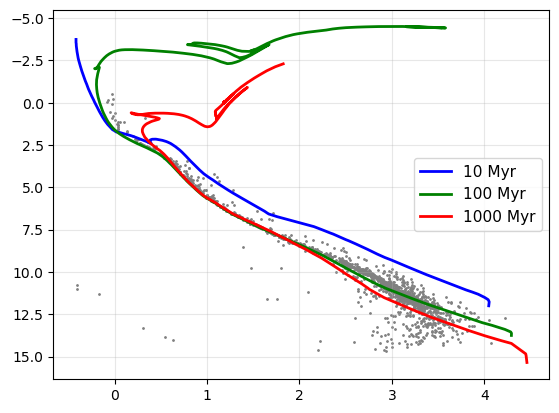

In [64]:
with open('parsec_3_nodoka.dat', 'r') as f:
    for i, line in enumerate(f):
        if i == 13:  # Line 14 (0-indexed)
            # Remove leading "# " and split
            header = line.strip().replace('# ', '').split()
            break

# Now read the data, skipping all comment lines
df = pd.read_csv('parsec_3_nodoka.dat', 
                 sep=r'\s+', 
                 comment='#',
                 names=header)

unique_ages = sorted(df['logAge'].unique())
print(f"\nAges present in file:")
for age in unique_ages:
    age_myr = 10**(age)   # logAge is log10(Age in Gyr), so convert to Myr
    print(f"  logAge = {age:.3f}  ({age_myr:.1f} Myr)")


# Plot 1: Gaia CMD (BP-RP vs G)
colors = ['blue', 'green', 'red', 'purple', 'orange']
for i, age in enumerate(unique_ages):
    iso = df[df['logAge'] == age]
    age_myr = 10**(age)/10**6  # Convert to Myr
    
    # Calculate color and magnitude
    color = iso['G_BP_fSBmag'] - iso['G_RP_fSBmag']
    mag = iso['G_fSBmag']
    
    # Plot
    plt.plot(color, mag, 
             label=f'{age_myr:.0f} Myr', 
             linewidth=2, 
             color=colors[i % len(colors)])
plt.scatter(dat['bp_rp'], dat['abs_mag'], s=1, alpha=1, color='grey')
plt.gca().invert_yaxis()
#plt.set_xlabel('BP - RP', fontsize=14)
#plt.set_ylabel('G (mag)', fontsize=14)
#plt.set_title('Pleiades Isochrones - Gaia CMD', fontsize=16, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

In [63]:
0.0134 * (10 ** (0.003))

0.013492884362614177

In [62]:

print("Column names:")
print(df.columns.tolist())

Column names:
['Zini', 'MH', 'logAge', 'Mini', 'int_IMF', 'Mass', 'logL', 'logTe', 'logg', 'label', 'McoreTP', 'C_O', 'period0', 'period1', 'period2', 'period3', 'period4', 'pmode', 'Mloss', 'tau1m', 'X', 'Y', 'Xc', 'Xn', 'Xo', 'Cexcess', 'Z', 'Teff0', 'omega', 'angvel', 'vtaneq', 'angmom', 'Rpol', 'Req', 'mbolmag', 'G_fSBmag', 'G_BP_fSBmag', 'G_RP_fSBmag', 'G_fSB', 'G_f0', 'G_fk', 'G_i00', 'G_i05', 'G_i10', 'G_i15', 'G_i20', 'G_i25', 'G_i30', 'G_i35', 'G_i40', 'G_i45', 'G_i50', 'G_i55', 'G_i60', 'G_i65', 'G_i70', 'G_i75', 'G_i80', 'G_i85', 'G_i90', 'G_BP_fSB', 'G_BP_f0', 'G_BP_fk', 'G_BP_i00', 'G_BP_i05', 'G_BP_i10', 'G_BP_i15', 'G_BP_i20', 'G_BP_i25', 'G_BP_i30', 'G_BP_i35', 'G_BP_i40', 'G_BP_i45', 'G_BP_i50', 'G_BP_i55', 'G_BP_i60', 'G_BP_i65', 'G_BP_i70', 'G_BP_i75', 'G_BP_i80', 'G_BP_i85', 'G_BP_i90', 'G_RP_fSB', 'G_RP_f0', 'G_RP_fk', 'G_RP_i00', 'G_RP_i05', 'G_RP_i10', 'G_RP_i15', 'G_RP_i20', 'G_RP_i25', 'G_RP_i30', 'G_RP_i35', 'G_RP_i40', 'G_RP_i45', 'G_RP_i50', 'G_RP_i55', 'G_R

In [3]:

# Read the PARSEC isochrone file
# The column names are on line 14 (13 if 0-indexed), starting with "# Zini"
# We need to read this line as the header and skip the previous comment lines

# First, read the header line
with open('ple_parsecs.dat', 'r') as f:
    for i, line in enumerate(f):
        if i == 13:  # Line 14 (0-indexed)
            # Remove leading "# " and split
            header = line.strip().replace('# ', '').split()
            break

# Now read the data, skipping all comment lines
df = pd.read_csv('ple_parsecs.dat', 
                 sep=r'\s+', 
                 comment='#',
                 names=header)

print("Column names:")
print(df.columns.tolist())
print(f"\nTotal rows: {len(df)}")
print(f"\nUnique ages (logAge): {sorted(df['logAge'].unique())}")
print(f"\nAge range in Myr: {10**(df['logAge'].min()) * 1000:.1f} - {10**(df['logAge'].max()) * 1000:.1f}")

# The file has G_fSBmag, G_BP_fSBmag, G_RP_fSBmag columns
# These are the standard Gaia magnitudes without extinction

# Filter for the three ages you requested (should be in the file)
# Let's find what ages are actually present
unique_ages = sorted(df['logAge'].unique())
print(f"\nAges present in file:")
for age in unique_ages:
    age_myr = 10**(age) * 1000  # logAge is log10(Age in Gyr), so convert to Myr
    print(f"  logAge = {age:.3f}  ({age_myr:.1f} Myr)")

# Create Color-Magnitude Diagram (CMD)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

# Plot 1: Gaia CMD (BP-RP vs G)
colors = ['blue', 'green', 'red', 'purple', 'orange']
for i, age in enumerate(unique_ages):
    iso = df[df['logAge'] == age]
    age_myr = 10**(age) * 1000  # Convert to Myr
    
    # Calculate color and magnitude
    color = iso['G_BP_fSBmag'] - iso['G_RP_fSBmag']
    mag = iso['G_fSBmag']
    
    # Plot
    ax1.plot(color, mag, 
             label=f'{age_myr:.0f} Myr', 
             linewidth=2, 
             color=colors[i % len(colors)])
ax1.scatter(ple['bp_rp'], ple['abs_mag'], s=1, alpha=1, color='grey')
ax1.invert_yaxis()
ax1.set_xlabel('BP - RP', fontsize=14)
ax1.set_ylabel('G (mag)', fontsize=14)
ax1.set_title('Pleiades Isochrones - Gaia CMD', fontsize=16, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: HR Diagram (log Teff vs log L)
for i, age in enumerate(unique_ages):
    iso = df[df['logAge'] == age]
    age_myr = 10**(age) * 1000  # Convert to Myr
    
    ax2.plot(iso['logTe'], iso['logL'], 
             label=f'{age_myr:.0f} Myr', 
             linewidth=2,
             color=colors[i % len(colors)])

ax2.invert_xaxis()  # Hot stars on the left
ax2.set_xlabel('log(Teff) [K]', fontsize=14)
ax2.set_ylabel('log(L/L☉)', fontsize=14)
ax2.set_title('Pleiades Isochrones - HR Diagram', fontsize=16, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/pleiades_isochrones.png', dpi=150, bbox_inches='tight')
print("\n✓ Saved plot to pleiades_isochrones.png")

# Additional analysis: Print some key statistics
print("\n" + "="*60)
print("ISOCHRONE STATISTICS")
print("="*60)

for age in unique_ages:
    iso = df[df['logAge'] == age]
    age_myr = 10**(age) * 1000  # Convert to Myr
    
    print(f"\n{age_myr:.0f} Myr isochrone:")
    print(f"  Mass range: {iso['Mini'].min():.3f} - {iso['Mini'].max():.3f} M☉")
    print(f"  Teff range: {10**iso['logTe'].min():.0f} - {10**iso['logTe'].max():.0f} K")
    print(f"  G mag range: {iso['G_fSBmag'].min():.2f} - {iso['G_fSBmag'].max():.2f}")
    print(f"  Color range (BP-RP): {(iso['G_BP_fSBmag'] - iso['G_RP_fSBmag']).min():.3f} - {(iso['G_BP_fSBmag'] - iso['G_RP_fSBmag']).max():.3f}")
    
    # Find the turnoff point (approximate)
    turnoff_idx = iso['logTe'].idxmax()
    turnoff = iso.loc[turnoff_idx]
    print(f"  Turnoff: Teff~{10**turnoff['logTe']:.0f}K, G~{turnoff['G_fSBmag']:.2f}, Mass~{turnoff['Mini']:.2f}M☉")

plt.show()

# Create a zoomed-in plot focusing on main sequence
fig2, ax = plt.subplots(figsize=(10, 10))

for i, age in enumerate(unique_ages):
    iso = df[df['logAge'] == age]
    age_myr = 10**(age) * 1000  # Convert to Myr
    
    # Filter for main sequence (roughly G < 15 for Pleiades distance ~135 pc)
    ms = iso[iso['G_fSBmag'] < 15]
    
    color = ms['G_BP_fSBmag'] - ms['G_RP_fSBmag']
    mag = ms['G_fSBmag']
    
    ax.plot(color, mag, 
            label=f'{age_myr:.0f} Myr', 
            linewidth=2.5,
            color=colors[i % len(colors)],
            marker='.',
            markersize=3,
            alpha=0.8)

ax.invert_yaxis()
ax.set_xlabel('BP - RP', fontsize=14)
ax.set_ylabel('G (mag)', fontsize=14)
ax.set_title('Pleiades Isochrones - Main Sequence (G < 15)', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.5, 4.5)

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/pleiades_isochrones_ms.png', dpi=150, bbox_inches='tight')
print("\n✓ Saved zoomed MS plot to pleiades_isochrones_ms.png")
plt.show()

NameError: name 'pd' is not defined

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astroquery.vizier import Vizier
from astropy.table import QTable
import astropy.units as u
from plot_xsl_dr3 import read_dr3_spec

a. Obtain a spectrum for an A star, and two others of different spectral type in luminosity
class V. Be sure to choose near-solar metallicity stars. Tabulate the ID, Teff , log g, and
[Fe/H] for the stars you choose.
Plot each spectrum and identify (on the plot) the major spectral lines that are used to
distinguish between spectral types. (Pay attention to lines that drop more than 25%
below the continuum surrounding the line.) When a line is visible in more than one of the
spectra, comment on the relative strengths of the lines and the physical reasons behind
the differences.

In [6]:
spec_name = r'xsl_spectrum_X0358_merged.fits'
[a_flux_temp, flux_tempdr_temp, a_waves_temp, unit, star, loss_corr, Av, Av_ori]= read_dr3_spec(spec_name, ang='on', star_kw='on', loss_corr_kw='on', av_kw = 'on')


 
File to read: xsl_spectrum_X0358_merged.fits


In [6]:
flux_temp

array([1.0093689e-12, 1.0136595e-12, 1.0308501e-12, ..., 2.6845659e-14,
       2.5148771e-14, 2.4558031e-14], shape=(58666,), dtype='>f4')

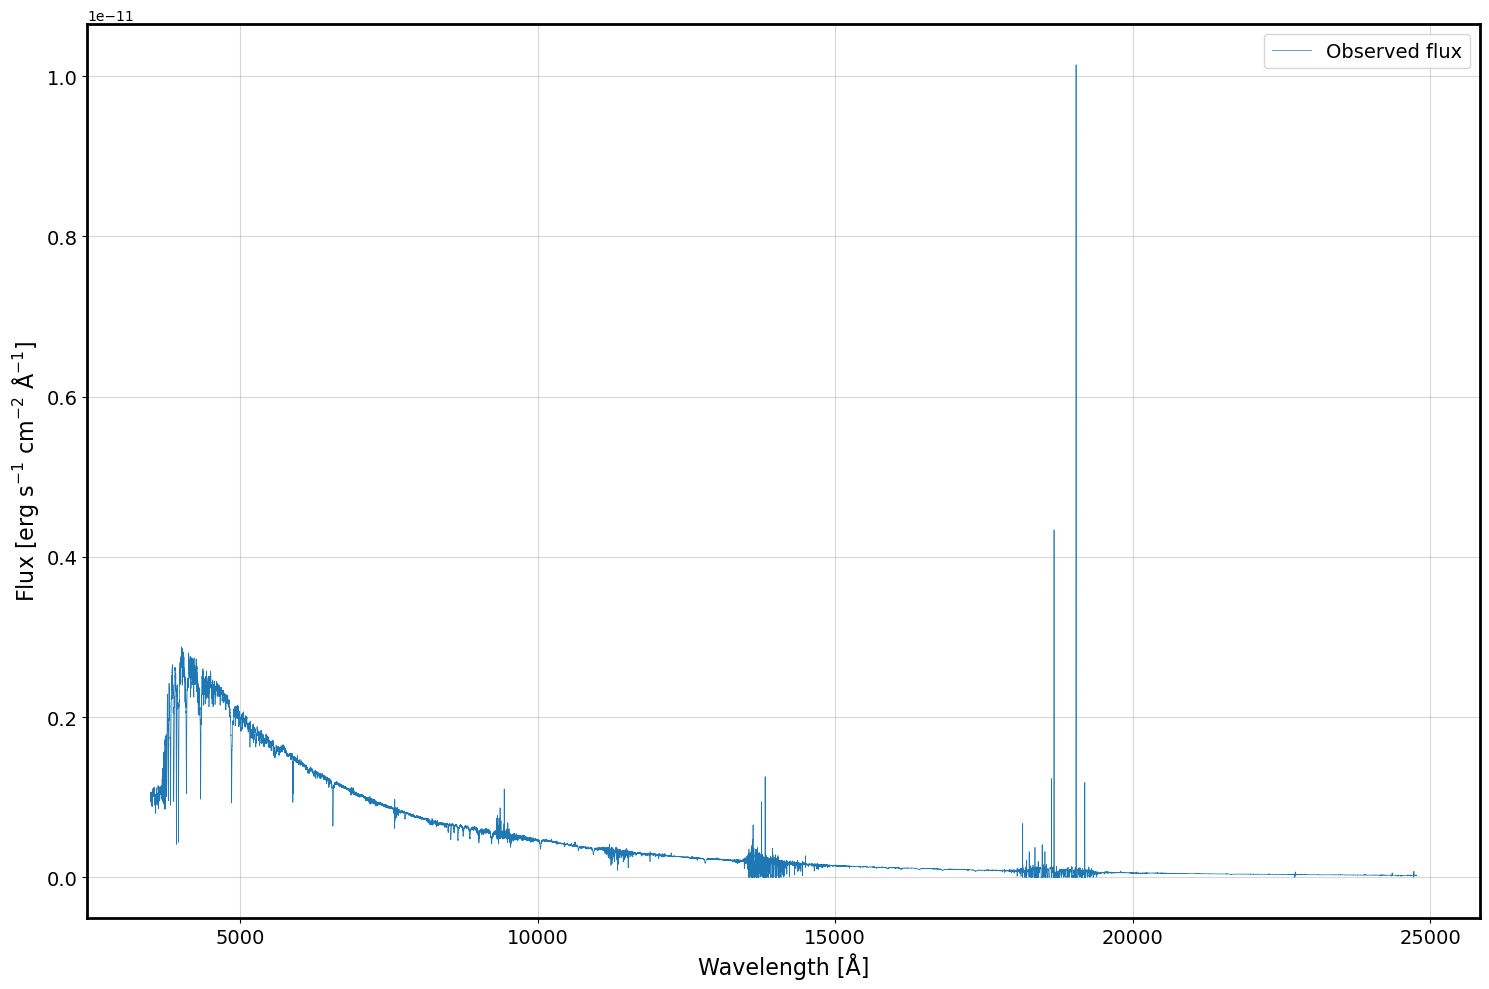

In [7]:
fig,ax = plt.subplots(figsize=(15, 10))
plt.plot(waves_temp, flux_temp, linewidth=0.5, label='Observed flux')
# plt.plot(waves_temp, flux_temp, 'b-', linewidth=0.5, label='Observed flux')
# if not np.all(np.isnan(flux_tempdr_temp)):
#     plt.plot(waves_temp, flux_tempdr_temp, 'r-', linewidth=0.5, label='Dereddened flux')
plt.xlabel(f'Wavelength [Å]',fontsize=16)
plt.ylabel('Flux [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]',fontsize=16)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x',labelsize=14)
ax.grid(alpha=0.5)

ax.legend(loc='upper right',fontsize=14)
plt.tight_layout()
#plt.savefig('HW1_Figs\CAMDe.png',dpi=300)
plt.show()

In [10]:
mask = (waves_temp < 12000)

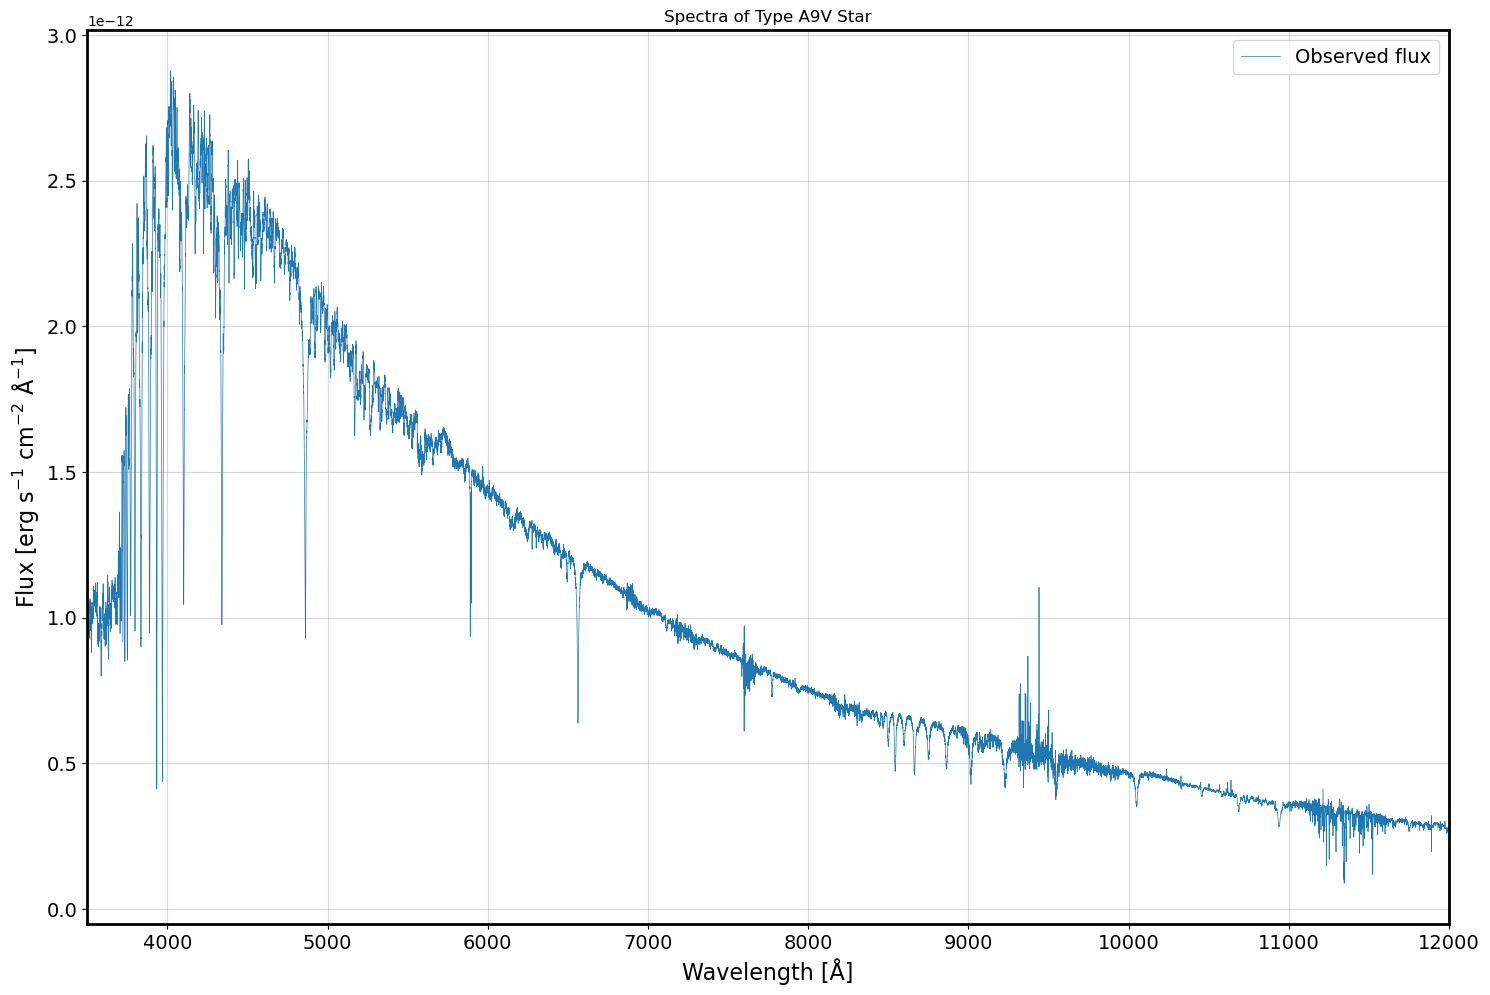

In [13]:
fig,ax = plt.subplots(figsize=(15, 10))
plt.plot(waves_temp[mask], flux_temp[mask], linewidth=0.5, label='Observed flux')
# plt.plot(waves_temp, flux_temp, 'b-', linewidth=0.5, label='Observed flux')
# if not np.all(np.isnan(flux_tempdr_temp)):
#     plt.plot(waves_temp, flux_tempdr_temp, 'r-', linewidth=0.5, label='Dereddened flux')
plt.xlabel(f'Wavelength [Å]',fontsize=16)
plt.ylabel('Flux [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]',fontsize=16)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x',labelsize=14)
ax.grid(alpha=0.5)

#ax.set_ylim(flux_temp.min(), flux_temp.max())
ax.set_xlim(waves_temp[0], 12000)
ax.legend(loc='upper right',fontsize=14)
plt.tight_layout()
plt.title('Spectra of Type A9V Star')
#plt.savefig('HW1_Figs\CAMDe.png',dpi=300)
plt.show()

In [19]:
# lines:
# hydrogen balmer lines
h_lines = [6562.81, 4861.34, 4340.48, 4101.75]

# calcium II k-line
caII_line = 3933.68

lines = h_lines
lines.append(caII_line)

for i, label in enumerate(mamajeknames):
    plt.annotate(label, (mamajekcol[i], mamajekG[i]), color='black')

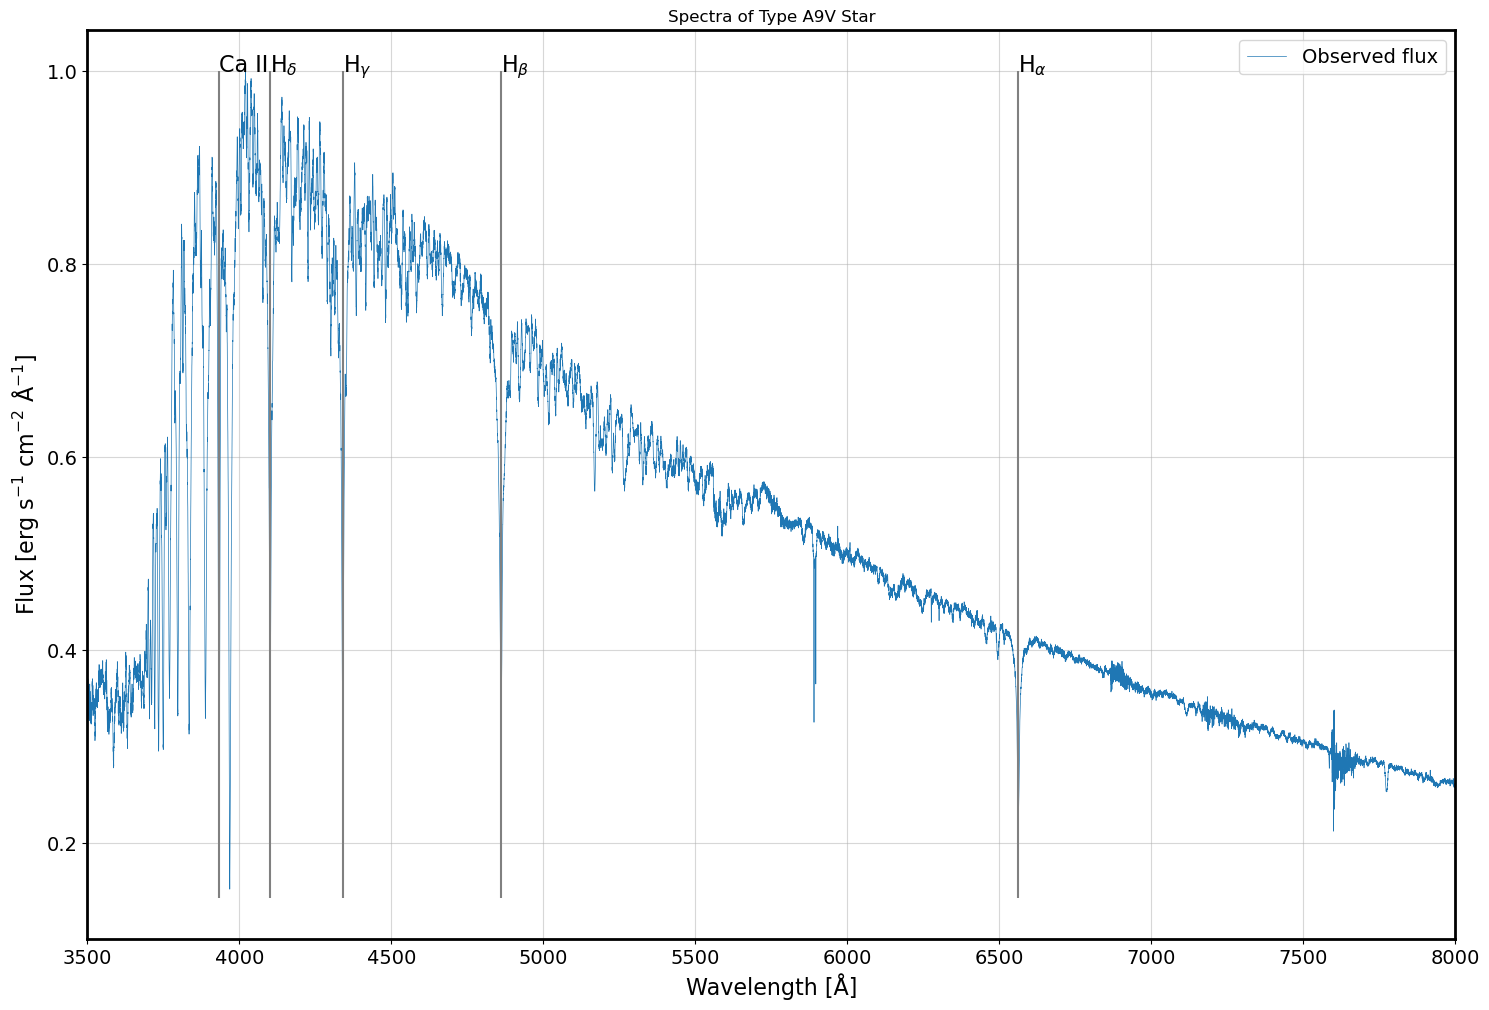

In [88]:
line_names = [r'H$_\alpha$', r'H$_\beta$', r'H$_\gamma$', r'H$_\delta$', r'Ca II']

maxf = flux_temp[mask].max()
minf = flux_temp[mask].min() / maxf

fig,ax = plt.subplots(figsize=(15, 10))
plt.plot(waves_temp[mask], flux_temp[mask]/maxf, linewidth=0.5, label='Observed flux')
# plt.plot(waves_temp, flux_temp, 'b-', linewidth=0.5, label='Observed flux')
# if not np.all(np.isnan(flux_tempdr_temp)):
#plt.plot(waves_temp, flux_tempdr_temp, 'r-', linewidth=0.5, label='Dereddened flux')
plt.xlabel(f'Wavelength [Å]',fontsize=16)
plt.ylabel('Flux [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]',fontsize=16)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x',labelsize=14)
ax.grid(alpha=0.5)


for i in range(5):
    ax.vlines(lines[i], ymin=minf, ymax=1.0, color='grey')
    ax.annotate(line_names[i], (lines[i], 1.), fontsize=16)
#ax.set_ylim(flux_temp.min(), flux_temp.max())
ax.set_xlim(waves_temp[0], 8000)
ax.legend(loc='upper right',fontsize=14)
plt.tight_layout()
plt.title('Spectra of Type A9V Star')
#plt.savefig('HW1_Figs\CAMDe.png',dpi=300)
plt.show()

<>:30: SyntaxWarning: invalid escape sequence '\A'
<>:33: SyntaxWarning: invalid escape sequence '\A'
<>:36: SyntaxWarning: invalid escape sequence '\A'
<>:39: SyntaxWarning: invalid escape sequence '\A'
<>:42: SyntaxWarning: invalid escape sequence '\A'
<>:30: SyntaxWarning: invalid escape sequence '\A'
<>:33: SyntaxWarning: invalid escape sequence '\A'
<>:36: SyntaxWarning: invalid escape sequence '\A'
<>:39: SyntaxWarning: invalid escape sequence '\A'
<>:42: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_66884/3820180141.py:30: SyntaxWarning: invalid escape sequence '\A'
  plt.axvline(lines[0], ymin=0.32, ymax=0.40, ls='--', color='black', lw=2, label=f'{line_names[0]}: {lines[0]} $\AA$')
/tmp/ipykernel_66884/3820180141.py:33: SyntaxWarning: invalid escape sequence '\A'
  plt.axvline(lines[1], ymin=0.65, ymax=0.75, ls='--', color='black', lw=2, label=f'{line_names[1]}: {lines[1]} $\AA$')
/tmp/ipykernel_66884/3820180141.py:36: SyntaxWarning: invalid escape sequence '\A'
 

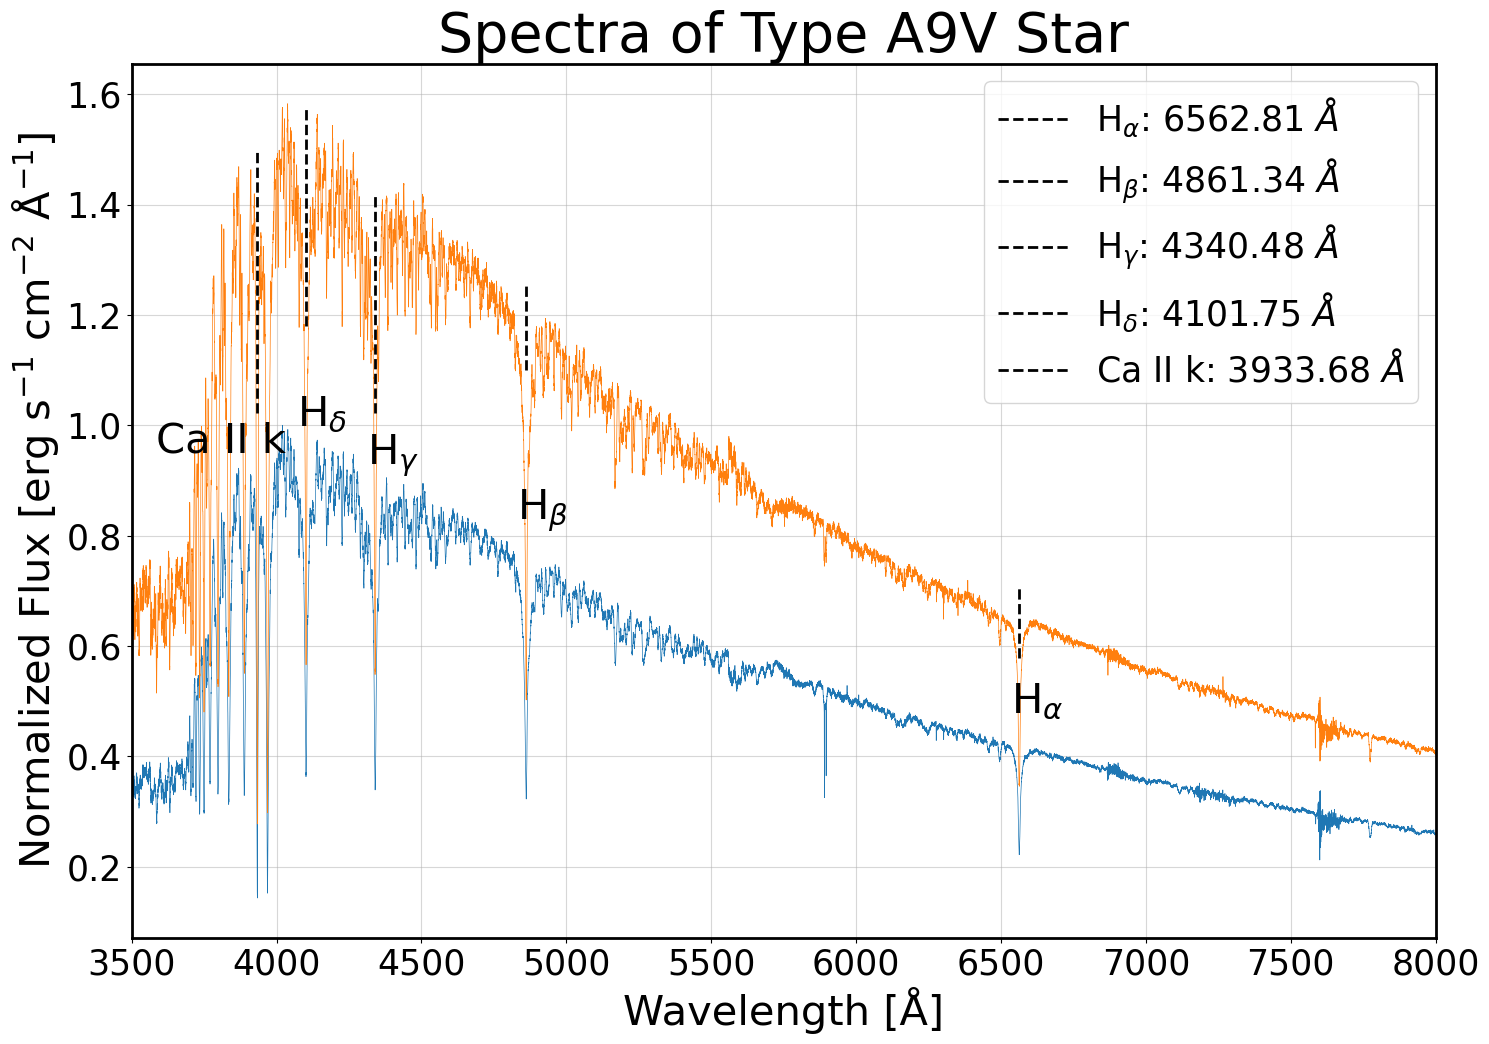

In [189]:
mask = (waves_temp < 8000)

line_names = [r'H$_\alpha$', r'H$_\beta$', r'H$_\gamma$', r'H$_\delta$', r'Ca II k']

maxf = a_flux_temp[mask].max()
minf = a_flux_temp[mask].min() / maxf

fig,ax = plt.subplots(figsize=(15, 10))
plt.plot(a_waves_temp[mask], a_flux_temp[mask]/maxf, linewidth=0.5)#, label='Observed flux')
plt.plot(waves_temp[mask], flux_temp[mask]/maxf, linewidth=0.5)#, label='Observed flux')

# plt.plot(waves_temp, flux_temp, 'b-', linewidth=0.5, label='Observed flux')
# if not np.all(np.isnan(flux_tempdr_temp)):
#     plt.plot(waves_temp, flux_tempdr_temp, 'r-', linewidth=0.5, label='Dereddened flux')
plt.xlabel(f'Wavelength [Å]',fontsize=30)
plt.ylabel('Normalized Flux [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]',fontsize=30)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.tick_params(axis='y', labelsize=25)
ax.tick_params(axis='x',labelsize=25)
ax.grid(alpha=0.5)

'''
for i in range(5):
    plt.vlines(lines[i], ymin=minf, ymax=1.0, color='grey')
    plt.annotate(line_names[i], (lines[i], 1.), fontsize=16)
'''
plt.axvline(lines[0], ymin=0.32, ymax=0.40, ls='--', color='black', lw=2, label=f'{line_names[0]}: {lines[0]} $\AA$')
plt.text(lines[0]-30,0.48, r'H$_\alpha$', fontsize=30)

plt.axvline(lines[1], ymin=0.65, ymax=0.75, ls='--', color='black', lw=2, label=f'{line_names[1]}: {lines[1]} $\AA$')
plt.text(lines[1]-30,0.83, r'H$_\beta$', fontsize=30)

plt.axvline(lines[2], ymin=0.60, ymax=0.85, ls='--', color='black', lw=2, label=f'{line_names[2]}: {lines[2]} $\AA$')
plt.text(lines[2]-30,0.93, r'H$_\gamma$', fontsize=30)

plt.axvline(lines[3], ymin=0.7, ymax=0.95, ls='--', color='black', lw=2, label=f'{line_names[3]}: {lines[3]} $\AA$')
plt.text(lines[3]-30,1, r'H$_\delta$', fontsize=30)

plt.axvline(lines[4], ymin=0.6, ymax=0.9, ls='--', color='black', lw=2, label=f'{line_names[4]}: {lines[4]} $\AA$')
plt.text(lines[4]-350,0.95, r'Ca II k', fontsize=30)

'''
plt.axvline(lines[0], ymin=0.32, ymax=0.40, ls='--', color='black', lw=2)
plt.text(lines[0]-30,0.48, r'H$_\alpha$', fontsize=30)
'''

#ax.set_ylim(flux_temp.min(), flux_temp.max())
plt.xlim(a_waves_temp[0], 8000)
plt.legend(loc='upper right',fontsize=25)
plt.tight_layout()
plt.title('Spectra of Type A9V Star', fontsize=40)
plt.savefig('2A_Aspec.png',dpi=100, bbox_inches='tight')
plt.show()

In [188]:
spec_f = r'xsl_spectrum_X0831_merged.fits'
[flux_temp, flux_tempdr_temp, waves_temp, unit, star, loss_corr, Av, Av_ori]= read_dr3_spec(spec_g, ang='on', star_kw='on', loss_corr_kw='on', av_kw = 'on')

 
File to read: xsl_spectrum_X0831_merged.fits


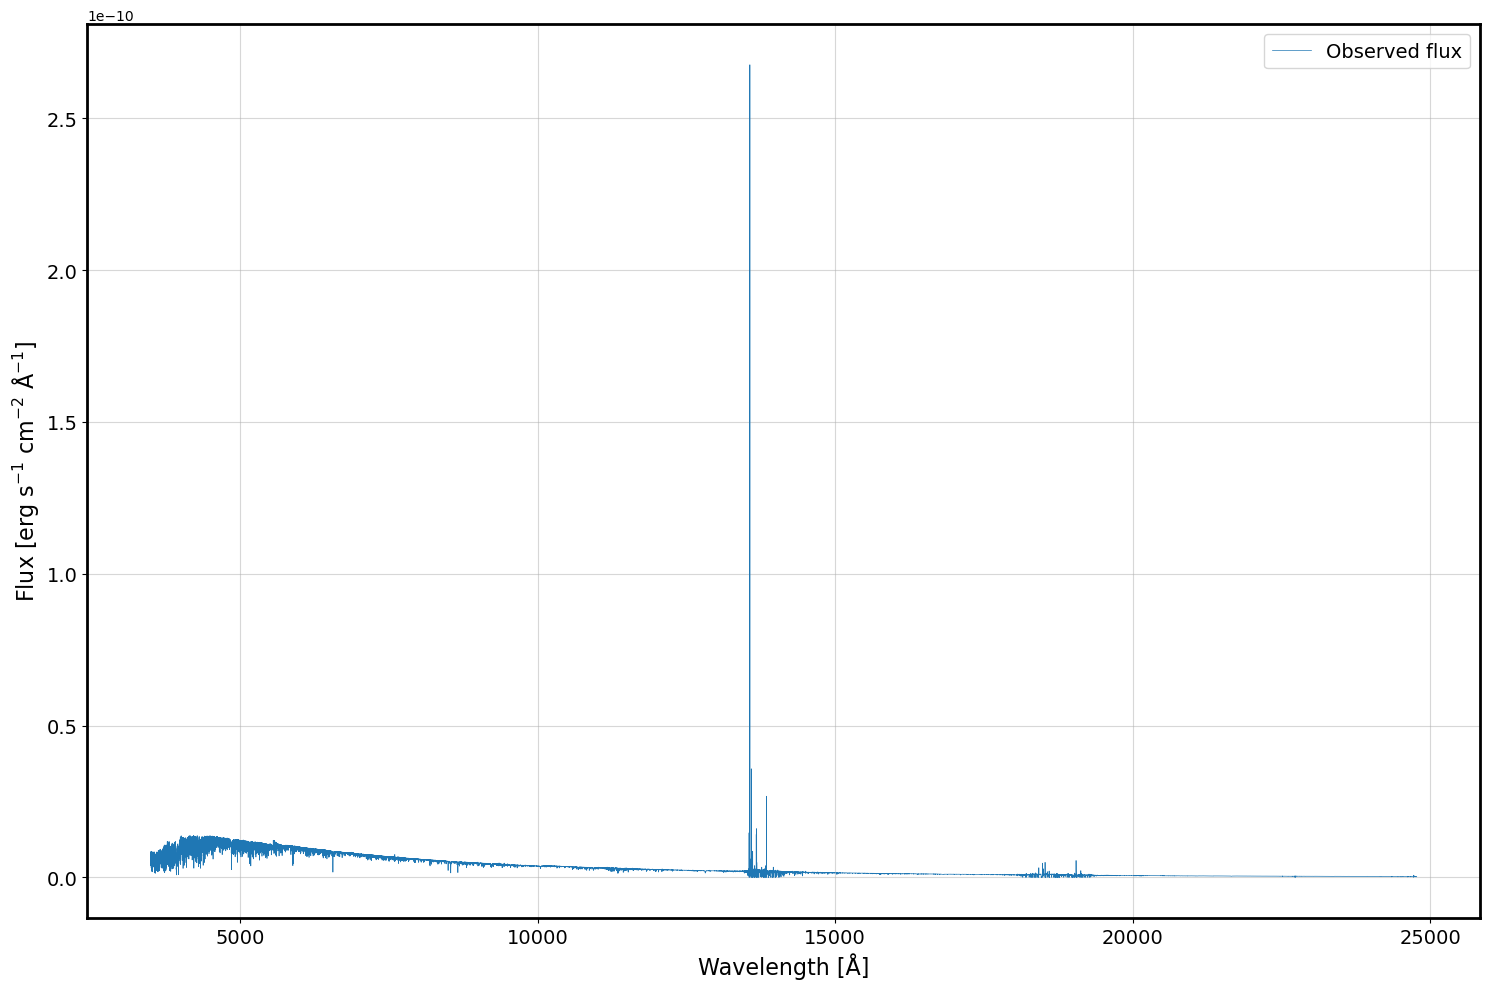

In [110]:
fig,ax = plt.subplots(figsize=(15, 10))
plt.plot(waves_temp, flux_temp, linewidth=0.5, label='Observed flux')
# plt.plot(waves_temp, flux_temp, 'b-', linewidth=0.5, label='Observed flux')
# if not np.all(np.isnan(flux_tempdr_temp)):
#     plt.plot(waves_temp, flux_tempdr_temp, 'r-', linewidth=0.5, label='Dereddened flux')
plt.xlabel(f'Wavelength [Å]',fontsize=16)
plt.ylabel('Flux [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]',fontsize=16)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x',labelsize=14)
ax.grid(alpha=0.5)

ax.legend(loc='upper right',fontsize=14)
plt.tight_layout()
#plt.savefig('HW1_Figs\CAMDe.png',dpi=300)
plt.show()

In [132]:
# lines:
# hydrogen balmer lines
h_lines = [6562.81, 4861.34, 4340.48, 4101.75]

# calcium II k-line: stronger in F
caII_line_k = 3933.68
caII_line_h = 3968.49
FeI = 3859.92
#CrI = 

lines = h_lines
lines.append(caII_line_k)
lines.append(caII_line_h)
lines.append(FeI)

<>:28: SyntaxWarning: invalid escape sequence '\A'
<>:31: SyntaxWarning: invalid escape sequence '\A'
<>:34: SyntaxWarning: invalid escape sequence '\A'
<>:37: SyntaxWarning: invalid escape sequence '\A'
<>:40: SyntaxWarning: invalid escape sequence '\A'
<>:43: SyntaxWarning: invalid escape sequence '\A'
<>:28: SyntaxWarning: invalid escape sequence '\A'
<>:31: SyntaxWarning: invalid escape sequence '\A'
<>:34: SyntaxWarning: invalid escape sequence '\A'
<>:37: SyntaxWarning: invalid escape sequence '\A'
<>:40: SyntaxWarning: invalid escape sequence '\A'
<>:43: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_66884/142409868.py:28: SyntaxWarning: invalid escape sequence '\A'
  plt.axvline(lines[0], ymin=0.32, ymax=0.40, ls='--', color='black', lw=2, label=f'{line_names[0]}: {lines[0]} $\AA$')
/tmp/ipykernel_66884/142409868.py:31: SyntaxWarning: invalid escape sequence '\A'
  plt.axvline(lines[1], ymin=0.65, ymax=0.75, ls='--', color='black', lw=2, label=f'{line_names[1]}: {li

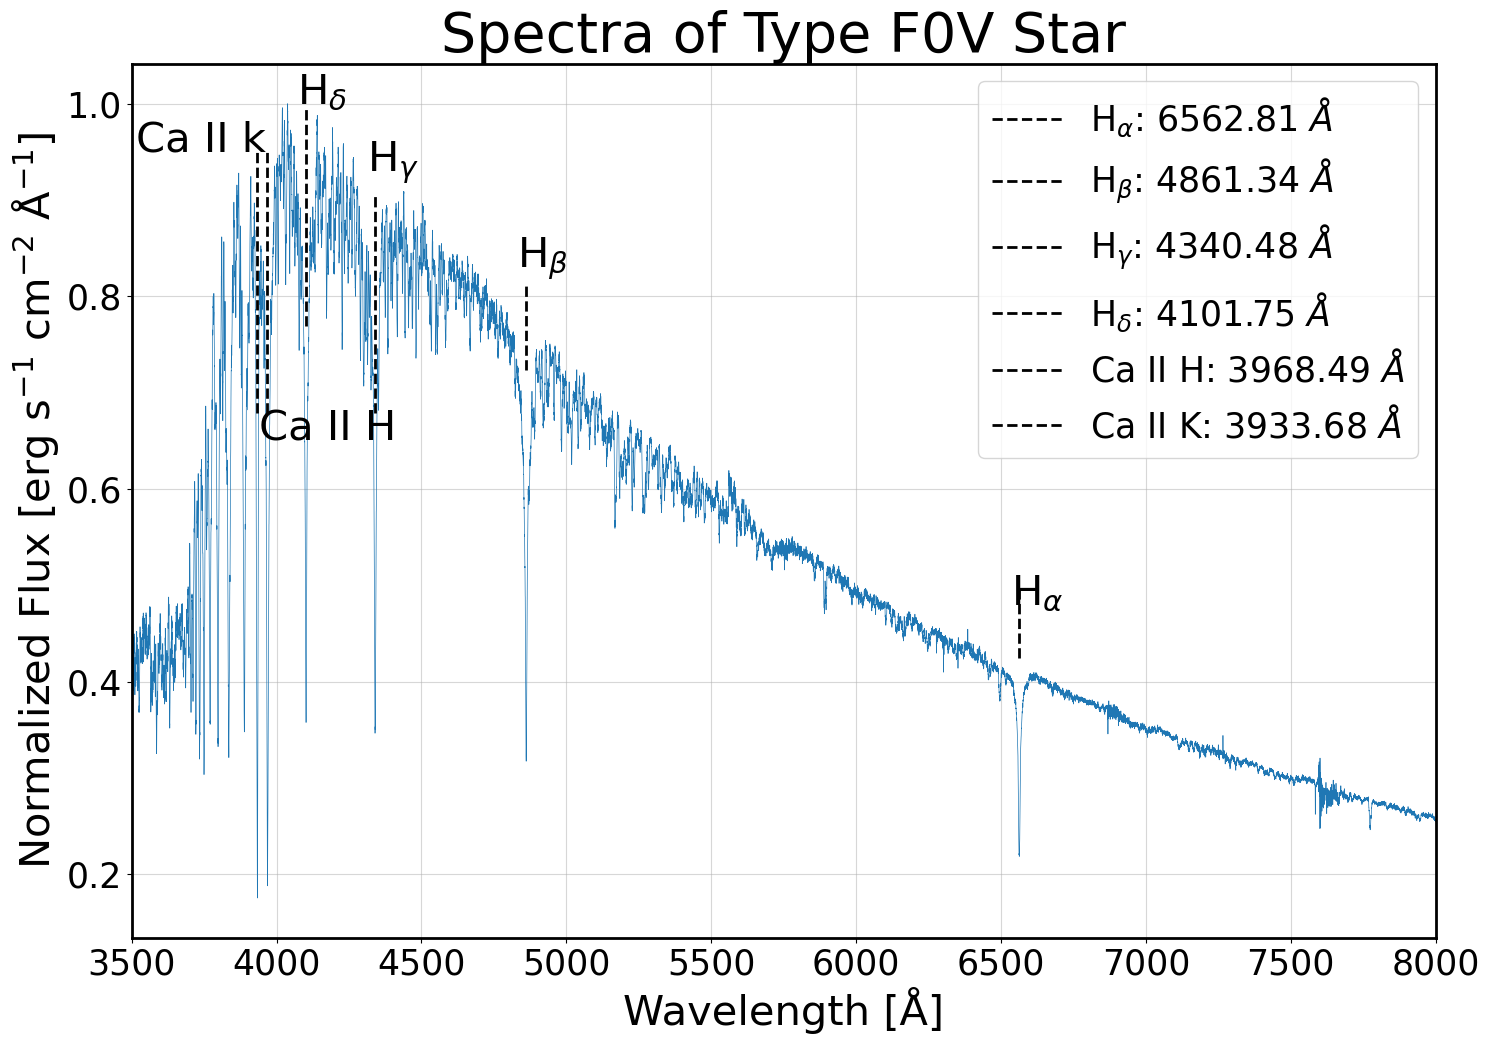

In [184]:
mask = (waves_temp < 8000)

line_names = [r'H$_\alpha$', r'H$_\beta$', r'H$_\gamma$', r'H$_\delta$', r'Ca II K', 'Ca II H', 'Fe I']

maxf = flux_temp[mask].max()
minf = flux_temp[mask].min() / maxf

fig,ax = plt.subplots(figsize=(15, 10))
plt.plot(waves_temp[mask], flux_temp[mask]/maxf, linewidth=0.5)#, label='Observed flux')
# plt.plot(waves_temp, flux_temp, 'b-', linewidth=0.5, label='Observed flux')
# if not np.all(np.isnan(flux_tempdr_temp)):
#     plt.plot(waves_temp, flux_tempdr_temp, 'r-', linewidth=0.5, label='Dereddened flux')
plt.xlabel(f'Wavelength [Å]',fontsize=30)
plt.ylabel('Normalized Flux [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]',fontsize=30)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.tick_params(axis='y', labelsize=25)
ax.tick_params(axis='x',labelsize=25)
ax.grid(alpha=0.5)

'''
for i in range(5):
    plt.vlines(lines[i], ymin=minf, ymax=1.0, color='grey')
    plt.annotate(line_names[i], (lines[i], 1.), fontsize=16)
'''
plt.axvline(lines[0], ymin=0.32, ymax=0.40, ls='--', color='black', lw=2, label=f'{line_names[0]}: {lines[0]} $\AA$')
plt.text(lines[0]-30,0.48, r'H$_\alpha$', fontsize=30)

plt.axvline(lines[1], ymin=0.65, ymax=0.75, ls='--', color='black', lw=2, label=f'{line_names[1]}: {lines[1]} $\AA$')
plt.text(lines[1]-30,0.83, r'H$_\beta$', fontsize=30)

plt.axvline(lines[2], ymin=0.60, ymax=0.85, ls='--', color='black', lw=2, label=f'{line_names[2]}: {lines[2]} $\AA$')
plt.text(lines[2]-30,0.93, r'H$_\gamma$', fontsize=30)

plt.axvline(lines[3], ymin=0.7, ymax=0.95, ls='--', color='black', lw=2, label=f'{line_names[3]}: {lines[3]} $\AA$')
plt.text(lines[3]-30,1, r'H$_\delta$', fontsize=30)

plt.axvline(lines[5], ymin=0.6, ymax=0.90, ls='--', color='black', lw=2,  label=f'{line_names[5]}: {lines[5]} $\AA$')
plt.text(lines[5]-30,0.65, line_names[5], fontsize=30)

plt.axvline(lines[4], ymin=0.6, ymax=0.9, ls='--', color='black', lw=2, label=f'{line_names[4]}: {lines[4]} $\AA$')
plt.text(lines[4]-420,0.95, r'Ca II k', fontsize=30)




#ax.set_ylim(flux_temp.min(), flux_temp.max())
plt.xlim(waves_temp[0], 8000)
plt.legend(loc='upper right',fontsize=25)
plt.tight_layout()
plt.title('Spectra of Type F0V Star', fontsize=40)
plt.savefig('2A_Fspec.png',dpi=300, bbox_inches='tight')



plt.show()

In [2]:
spec_f = r'xsl_spectrum_X0303_merged_ncl_ncge.fits'
[flux_temp, flux_tempdr_temp, waves_temp, unit, star, loss_corr, Av, Av_ori]= read_dr3_spec(spec_f, ang='on', star_kw='on', loss_corr_kw='on', av_kw = 'on')

 
File to read: xsl_spectrum_X0303_merged_ncl_ncge.fits
spectrum IS NOT corrected for galactic dust extinction.
De-reddened spectra unavailable.


In [3]:
blines = [6562.81, 4861.34, 4340.48, 4101.75, 3889, 4471, 5016, 
         4481]

#lines:
# H balmer:
# He I absorption
#  Mg II
# not add : O II, N II

<>:28: SyntaxWarning: invalid escape sequence '\A'
<>:28: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_86098/2344762210.py:28: SyntaxWarning: invalid escape sequence '\A'
  plt.axvline(lines[0], ymin=0.32, ymax=0.40, ls='--', color='black', lw=2, label=f'{line_names[0]}: {lines[0]} $\AA$')
/tmp/ipykernel_86098/2344762210.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right',fontsize=25)


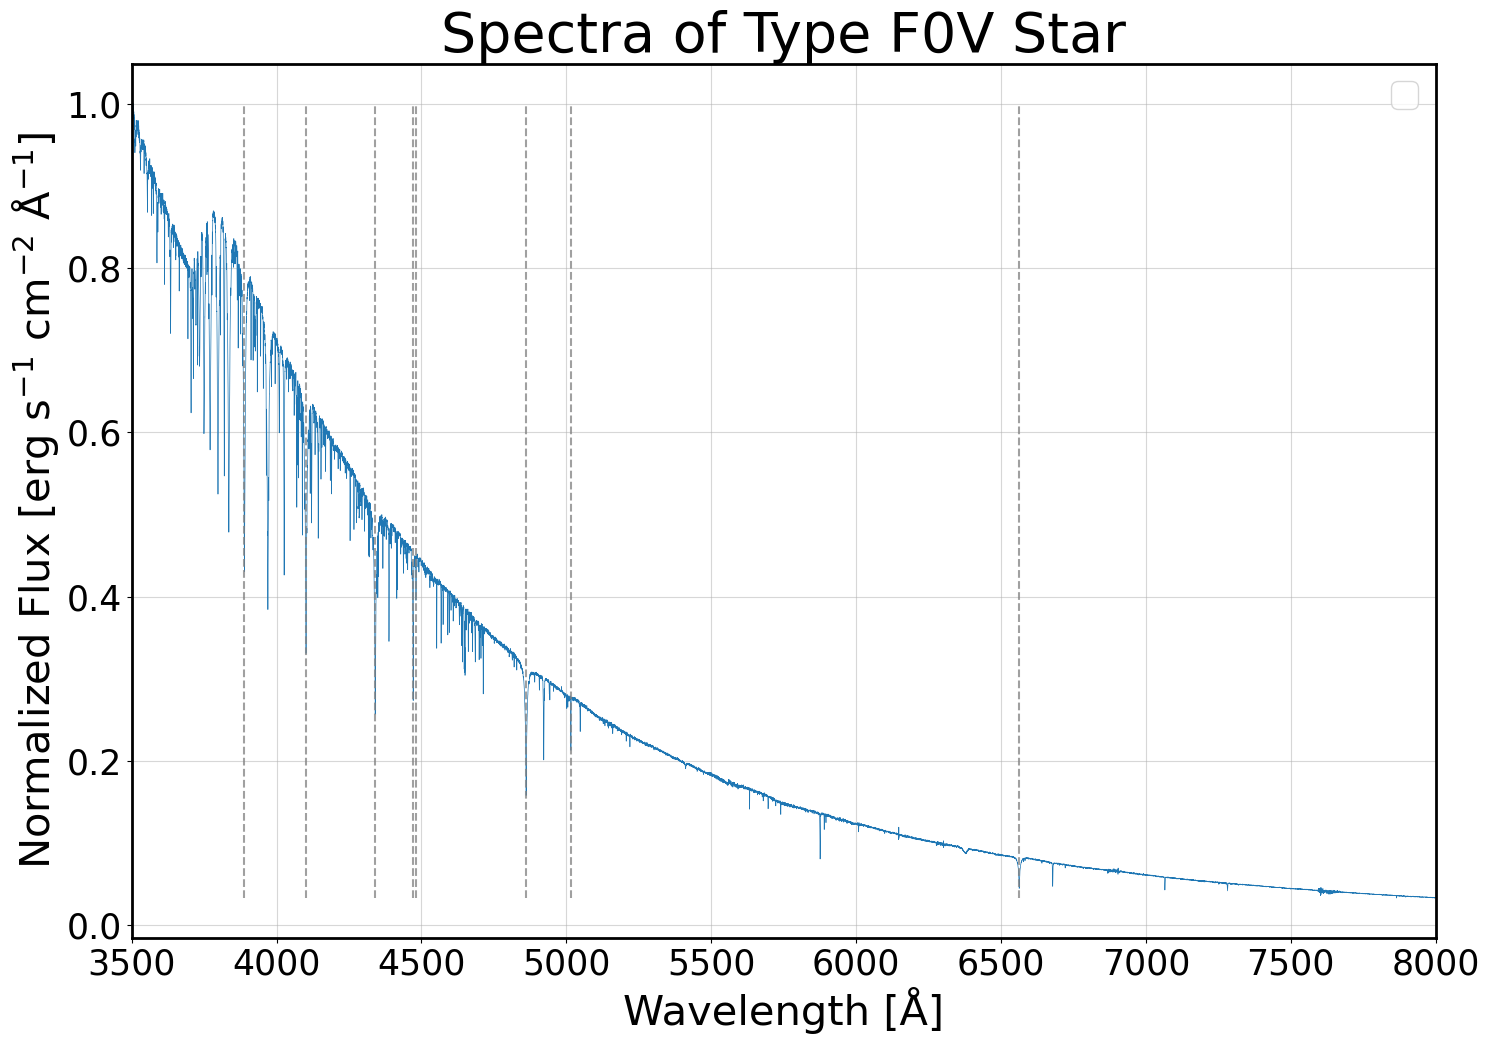

In [4]:
mask = (waves_temp < 8000)

line_names = [r'H$_\alpha$', r'H$_\beta$', r'H$_\gamma$', r'H$_\delta$', r'Ca II K', 'Ca II H', 'Fe I']

maxf = flux_temp[mask].max()
minf = flux_temp[mask].min() / maxf

fig,ax = plt.subplots(figsize=(15, 10))
plt.plot(waves_temp[mask], flux_temp[mask]/maxf, linewidth=0.5)#, label='Observed flux')
# plt.plot(waves_temp, flux_temp, 'b-', linewidth=0.5, label='Observed flux')
# if not np.all(np.isnan(flux_tempdr_temp)):
#     plt.plot(waves_temp, flux_tempdr_temp, 'r-', linewidth=0.5, label='Dereddened flux')
plt.xlabel(f'Wavelength [Å]',fontsize=30)
plt.ylabel('Normalized Flux [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]',fontsize=30)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.tick_params(axis='y', labelsize=25)
ax.tick_params(axis='x',labelsize=25)
ax.grid(alpha=0.5)


for line in blines:
    plt.vlines(line, ymin=minf, ymax=1.0, color='grey', ls='--', alpha=0.75)
    #plt.annotate(line_names[i], (lines[i], 1.), fontsize=16)
'''
plt.axvline(lines[0], ymin=0.32, ymax=0.40, ls='--', color='black', lw=2, label=f'{line_names[0]}: {lines[0]} $\AA$')
plt.text(lines[0]-30,0.48, r'H$_\alpha$', fontsize=30)

plt.axvline(lines[1], ymin=0.65, ymax=0.75, ls='--', color='black', lw=2, label=f'{line_names[1]}: {lines[1]} $\AA$')
plt.text(lines[1]-30,0.83, r'H$_\beta$', fontsize=30)

plt.axvline(lines[2], ymin=0.60, ymax=0.85, ls='--', color='black', lw=2, label=f'{line_names[2]}: {lines[2]} $\AA$')
plt.text(lines[2]-30,0.93, r'H$_\gamma$', fontsize=30)

plt.axvline(lines[3], ymin=0.7, ymax=0.95, ls='--', color='black', lw=2, label=f'{line_names[3]}: {lines[3]} $\AA$')
plt.text(lines[3]-30,1, r'H$_\delta$', fontsize=30)

plt.axvline(lines[5], ymin=0.6, ymax=0.90, ls='--', color='black', lw=2,  label=f'{line_names[5]}: {lines[5]} $\AA$')
plt.text(lines[5]-30,0.65, line_names[5], fontsize=30)

plt.axvline(lines[4], ymin=0.6, ymax=0.9, ls='--', color='black', lw=2, label=f'{line_names[4]}: {lines[4]} $\AA$')
plt.text(lines[4]-420,0.95, r'Ca II k', fontsize=30)

'''


#ax.set_ylim(flux_temp.min(), flux_temp.max())
plt.xlim(waves_temp[0], 8000)
plt.legend(loc='upper right',fontsize=25)
plt.tight_layout()
plt.title('Spectra of Type F0V Star', fontsize=40)
plt.savefig('2A_Fspec.png',dpi=300, bbox_inches='tight')



plt.show()

c. For the A0 and one other star, integrate the spectrum in the B and V filter ranges,
and find the ratio FB /FV for each. If an A0 star is defined to have a color B − V = 0,
determine the color of the other star.

In [8]:
'''
# Define the function to integrate
def f(x):
    return np.sin(x)

# Compute the definite integral of sin(x) from 0 to pi
result, error = spi.quad(f, 0, np.pi)

print(f"Integral result: {result}")
print(f"Estimated error: {error}")
'''

# B : centered at 440 nm + 98 nm bandwidth:
b_min = 4400 - 0.5 * 98
b_max = 4400 + 0.5 * 98

# V : centered at 550 nm + 89 nm bandwidth:
v_min = 5500 - 0.5 * 89
v_max = 5500 + 0.5 * 89
 

In [180]:
spec_name = r'xsl_spectrum_X0358_merged.fits'
[flux_temp, flux_tempdr_temp, waves_temp, unit, star, loss_corr, Av, Av_ori]= read_dr3_spec(spec_name, ang='on', star_kw='on', loss_corr_kw='on', av_kw = 'on')

 
File to read: xsl_spectrum_X0358_merged.fits


In [9]:
# Example data (replace with your actual data)
#wavelength = np.array([400, 450, 500, 550, 600, 650, 700, 750, 800])  # in nm
#flux = np.array([1.2, 1.8, 2.5, 3.1, 2.9, 2.3, 1.7, 1.2, 0.8])  # arbitrary units

# Define integration range
#wavelength_start = 500  # start wavelength
#wavelength_end = 700    # end wavelength

# Method 1: Trapezoidal Rule (most common, good for general use)
# This is the most commonly used method for discrete data
v_mask = (a_waves_temp >= v_min) & (a_waves_temp <= v_max)
v_wl_range = a_waves_temp[v_mask]
v_flux_range = a_flux_temp[v_mask]

F_v_a = np.trapezoid(v_flux_range, v_wl_range)

b_mask = (a_waves_temp >= b_min) & (a_waves_temp <= b_max)
b_wl_range = a_waves_temp[b_mask]
b_flux_range = a_flux_temp[b_mask]

F_b_a = np.trapezoid(b_flux_range, b_wl_range)

A_rat = F_b_a/F_v_a
A_rat

np.float32(1.5651839)

In [10]:
v_mask = (waves_temp >= v_min) & (waves_temp <= v_max)
v_wl_range = waves_temp[v_mask]
v_flux_range = flux_temp[v_mask]

F_v_a = np.trapezoid(v_flux_range, v_wl_range)

b_mask = (waves_temp >= b_min) & (waves_temp <= b_max)
b_wl_range = waves_temp[b_mask]
b_flux_range = flux_temp[b_mask]

F_b_a = np.trapezoid(b_flux_range, b_wl_range)

B_rat = F_b_a/F_v_a
B_rat

np.float32(2.8556967)

In [17]:
Z = 2.5 * np.log10(A_rat) + 0.3
Z - 2.5 * np.log10(B_rat)

np.float32(-0.35286683)

d) For one spectrum with a noticeable optical Hβ line, “normalize” the spectrum by fitting
the continuum and setting that to 1. Plot the normalized spectrum around the Hβ line,
and compute the equivalent width.

e) Obtain a theoretical flux distribution from the ATLAS9 repository for the characteris-
tics of one of your non-A0 stars. Provide a plot of the comparison with the XSL data, and
give the Teff and log g values you used. Describe briefly how you normalized the model to
the data, and comment on the degree of agreement between the two.